In [3]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image

# Step 1: Download and load the MNIST dataset
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Ensure it's grayscale
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize images to have values between -1 and 1
])

# Download MNIST training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

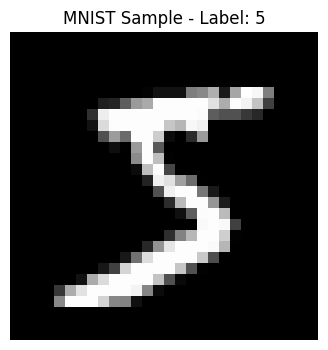

Image shape: torch.Size([1, 28, 28])
Value range: [-1.00, 1.00]


In [5]:
# Step 2: Visualize a sample image
import matplotlib.pyplot as plt

# Get a sample image from the training dataset
sample_idx = 0  # Index of the sample to visualize
sample_img, sample_label = train_dataset[sample_idx]

# Convert tensor to numpy for visualization
sample_img_np = sample_img.squeeze().numpy()  # Remove channel dimension and convert to numpy

# Plot the image
plt.figure(figsize=(4, 4))
plt.imshow(sample_img_np, cmap='gray')
plt.title(f'MNIST Sample - Label: {sample_label}')
plt.axis('off')
plt.show()

# Print image shape and value range
print(f"Image shape: {sample_img.shape}")
print(f"Value range: [{sample_img.min():.2f}, {sample_img.max():.2f}]")

In [8]:

# Step 3: Create image patches (16x16 patches)
def create_image_patches(image, patch_size=14):
    """
    Given an image, create patches of specified size (patch_size x patch_size).
    """
    patches = []
    img = image.numpy().squeeze()  # Convert to numpy array
    for i in range(0, img.shape[0], patch_size):
        for j in range(0, img.shape[1], patch_size):
            patch = img[i:i+patch_size, j:j+patch_size]
            patches.append(patch)
    
    patches = np.array(patches)
    patches = patches.reshape(len(patches), patch_size * patch_size)  # Flatten each patch
    return patches

# Step 4: Create DataLoader for training and testing
def collate_fn(batch):
    # Collate function to group patches into a batch
    images = [item[0] for item in batch]
    labels = [item[1] for item in batch]

    # Create patches for each image
    patch_list = []
    for image in images:
        patches = create_image_patches(image)
        patch_list.append(patches)

    # Stack patches for batch
    patches = torch.tensor(np.array(patch_list))
    labels = torch.tensor(np.array(labels))
    return patches, labels


# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, collate_fn=collate_fn)

# Example: Get a batch of patches and labels
for patches, labels in train_loader:
    print("Batch of patches shape:", patches.shape)
    print("Batch of labels shape:", labels.shape)
    break



Batch of patches shape: torch.Size([256, 4, 196])
Batch of labels shape: torch.Size([256])
